# Lecture 3 — Your First Calls

**Module 3: Pythonic LLM Engineering**

Run this locally, from your project folder:

```bash
uv run jupyter lab
```

Four labs, roughly fifteen minutes each. Your lecturer will tell you when to start each one — do not run ahead.

Everything you write today, you keep. The wrapper you build in Lab 4 is used for the rest of the module.

---
## Setup

This should already work from your homework. If it does not, put your hand up.

In [1]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
)

MODEL = "openai/gpt-oss-20b"

print("client ready, model:", MODEL)

client ready, model: openai/gpt-oss-20b


### A small helper

Different providers name the output-limit parameter differently. This wrapper tries the modern name and falls back to the older one, so the rest of the notebook works whichever your provider expects.

This is a small taste of a real problem: *compatible* APIs are compatible until they are not.

In [2]:
def call(messages, model=None, max_out=None, **kwargs):
    """One call. Returns the raw response object."""
    args = dict(model=model or MODEL, messages=messages, **kwargs)
    if max_out is not None:
        args["max_completion_tokens"] = max_out
    try:
        return client.chat.completions.create(**args)
    except Exception as e:
        if max_out is not None and "max_completion_tokens" in str(e):
            args.pop("max_completion_tokens")
            args["max_tokens"] = max_out
            return client.chat.completions.create(**args)
        raise


def show(r):
    """Print the four things you should look at on every call."""
    c = r.choices[0]
    print("content       :", c.message.content)
    print("finish_reason :", c.finish_reason)
    print("input tokens  :", r.usage.prompt_tokens)
    print("output tokens :", r.usage.completion_tokens)


print("helpers ready")

helpers ready


---
# Lab 1 — Your first call

*Fifteen minutes.*

### 1a. Make one call

In [3]:
messages = [
    {"role": "system", "content": "You answer in one sentence."},
    {"role": "user",   "content": "What is a context window?"},
]

r = call(messages)
show(r)

content       : A context window is the span of tokens a language model processes at once, limiting how much prior text it can “see” to generate or predict the next word.
finish_reason : stop
input tokens  : 86
output tokens : 69


**Write down** the two token counts. You will compare against them in a moment.

Input tokens: 86
Output tokens: 69

### 1b. Make the system prompt do some work

Same question, three different system prompts. Watch what happens to `completion_tokens` — and to the bill, since output is the expensive side.

In [8]:
question = "What is a context window?"

prompts = {
    "one word":       "Answer in exactly one word.",
    "one sentence":   "You answer in one sentence.",
    "three paragraphs": "Answer in three full paragraphs with examples.",
}

for name, system in prompts.items():
    r = call([
        {"role": "system", "content": system},
        {"role": "user",   "content": question},
    ])
    print(f"{name:<18} in={r.usage.prompt_tokens:>4}  out={r.usage.completion_tokens:>4}")

one word           in=  86  out= 210
one sentence       in=  86  out= 165
three paragraphs   in=  88  out= 503


**Question for your group.** The input barely moved and the output changed a lot. Which side of the bill does a system prompt actually control?

The output tokens are the ones influenced by a system prompt.

### 1c. Is it deterministic?

Send the identical request five times and compare what comes back.

In [10]:
answers = []
for i in range(5):
    r = call([{"role": "user", "content": "Name three causes of chest pain."}])
    answers.append(r.choices[0].message.content)

identical = len(set(answers)) == 1
print("byte-identical across all five:", identical)
print("distinct answers:", len(set(answers)))
print()
for i, a in enumerate(answers, 1):
    print(f"--- {i} ---")
    print(a[:200])
    print()

byte-identical across all five: False
distinct answers: 5

--- 1 ---
Three common causes of chest pain include:  

1. **Cardiac causes** – such as a heart attack (myocardial infarction) or angina (reduced blood flow to the heart).  
2. **Gastroesophageal reflux disease

--- 2 ---
Chest pain can stem from many different sources. Here are three common causes:

| Cause | Typical features |
|-------|------------------|
| **Cardiac (e.g., angina or heart attack)** | Pressure‑like o

--- 3 ---
Three common causes of chest pain are:

1. **Cardiac issues** – such as a heart attack (myocardial infarction) or angina, where the heart muscle isn’t getting enough oxygen‑rich blood.  
2. **Pulmonar

--- 4 ---
Three common causes of chest pain include:

1. **Cardiac causes** – e.g., a heart attack (myocardial infarction) or angina pectoris, where the heart muscle isn’t getting enough oxygen‑rich blood.  
2.

--- 5 ---
Three common causes of chest pain are:

1. **Cardiac** – e.g., angina or a heart at

No the outcome is not deterministic. 
Since the model predicts a list of tokens + probability and then based on its temperature picks one of these at random. 
After 2 outcomes differ by a single token choice the rest of the models output decisions will likely start to drift apart.

### 1d. Now pin the temperature

In [11]:
answers = []
for i in range(5):
    r = call(
        [{"role": "user", "content": "Name three causes of chest pain."}],
        temperature=0,
    )
    answers.append(r.choices[0].message.content)

print("byte-identical at temperature=0:", len(set(answers)) == 1)
print("distinct answers:", len(set(answers)))

byte-identical at temperature=0: False
distinct answers: 2


**Questions.**

1. How many of your first five were byte-identical? How many were identical in *meaning*?
2. Did `temperature=0` make them identical? Did it make them *guaranteed* identical?
3. If you wanted to write a test asserting the answer equals an expected string, would that test pass reliably?

1. 0 Were byte-identical. In meaning they were all.
2. Not byte-identical. I received 2 distinct answers.
3. Looking at this output, no. I believe this is because while the choice of the next token will always choose the most likely pick, the most likely pick still has randomness built in based on the computational process to built that list of potential output tokens.

Have your number for question 1 ready — the room compares.

---
# Lab 2 — Tokens and cost

*Fifteen minutes.*

In [12]:
import tiktoken

enc = tiktoken.get_encoding("o200k_base")

def count(text):
    return len(enc.encode(text))

def pieces(text):
    return [enc.decode([i]) for i in enc.encode(text)]

print("tokenizer ready, vocabulary:", enc.n_vocab)

tokenizer ready, vocabulary: 200019


### 2a. The gap between your count and your bill

Count a question locally. Then send it and look at what the API charged for.

In [13]:
question = "What is a context window?"

local = count(question)

r = call([{"role": "user", "content": question}], max_out=1)
charged = r.usage.prompt_tokens

print(f"tiktoken counted    : {local}")
print(f"the API charged for : {charged}")
print(f"overhead            : {charged - local} tokens you never typed")

tiktoken counted    : 6
the API charged for : 77
overhead            : 71 tokens you never typed


Those extra tokens are the **chat template** — the role markers and delimiters from last week's Station 1. You pay for them on every single call.

### 2b. Does a system prompt change the overhead?

In [14]:
with_system = [
    {"role": "system", "content": "You are helpful."},
    {"role": "user",   "content": question},
]

r2 = call(with_system, max_out=1)

local2 = count("You are helpful.") + count(question)
print(f"tiktoken counted    : {local2}")
print(f"the API charged for : {r2.usage.prompt_tokens}")
print(f"overhead            : {r2.usage.prompt_tokens - local2}")
print()
print(f"overhead grew by {(r2.usage.prompt_tokens - local2) - (charged - local)} tokens when we added one message")

tiktoken counted    : 10
the API charged for : 84
overhead            : 74

overhead grew by 3 tokens when we added one message


**Question.** Is the overhead a fixed cost per call, or does it grow with the number of messages? What does that imply for a long conversation?

The overhead cost-per-call grows with the number of messages in the conversation. This means longer conversations will contain more overhead tokens per message, thus increasing cost over time.

### 2c. Your own Dutch ratio

Last week a group researched this. Now measure it yourself. Replace the paragraphs with your own if you like — just make sure they really say the same thing.

In [15]:
english = (
    "The patient was admitted to the hospital yesterday evening with chest pain. "
    "After an examination, the cardiologist decided to keep her under observation "
    "until the results of the blood tests were available."
)

dutch = (
    "De patiënt werd gisteravond met pijn op de borst in het ziekenhuis opgenomen. "
    "Na een onderzoek besloot de cardioloog haar ter observatie te houden "
    "totdat de uitslagen van het bloedonderzoek beschikbaar waren."
)

en, nl = count(english), count(dutch)
print(f"English : {en:>4} tokens   {len(english):>4} characters")
print(f"Dutch   : {nl:>4} tokens   {len(dutch):>4} characters")
print(f"\nratio   : {nl / en:.2f}x")

English :   36 tokens    205 characters
Dutch   :   40 tokens    208 characters

ratio   : 1.11x


In [16]:
# Which words fragment worst? Add your own.
words = [
    "hospital", "ziekenhuis",
    "admission", "ziekenhuisopname",
    "insurance", "zorgverzekering",
    "arbeidsongeschiktheidsverzekering",
]

print(f"{'word':<36}{'chars':>6}{'tokens':>8}{'per token':>11}   split")
print("-" * 100)
for w in words:
    c, t = len(w), count(w)
    print(f"{w:<36}{c:>6}{t:>8}{c / t:>11.1f}   {' | '.join(pieces(w))}")

word                                 chars  tokens  per token   split
----------------------------------------------------------------------------------------------------
hospital                                 8       1        8.0   hospital
ziekenhuis                              10       3        3.3   zie | ken | huis
admission                                9       2        4.5   ad | mission
ziekenhuisopname                        16       5        3.2   zie | ken | huis | op | name
insurance                                9       1        9.0   insurance
zorgverzekering                         15       2        7.5   zorg | verzekering
arbeidsongeschiktheidsverzekering       33       8        4.1   arbe | ids | ong | esch | ik | the | ids | verzekering


### 2d. Put a price on it

In [17]:
# Groq is free. Treat these as the rates you would pay on a hosted provider.
IN_RATE, OUT_RATE = 0.20, 1.20    # dollars per 1,000,000 tokens

def cost(usage):
    return (usage.prompt_tokens * IN_RATE
            + usage.completion_tokens * OUT_RATE) / 1_000_000


task = "Summarise the purpose of a hospital triage system."
variants = {
    "one line":            f"{task} Answer in one line.",
    "one paragraph":       f"{task} Answer in one paragraph.",
    "paragraph + example": f"{task} Answer in one paragraph with a concrete example.",
}

results = {}
for name, prompt in variants.items():
    r = call([{"role": "user", "content": prompt}])
    results[name] = r
    print(f"{name:<22} in={r.usage.prompt_tokens:>4}  out={r.usage.completion_tokens:>4}  ${cost(r.usage):.6f}")

cheapest = min(cost(r.usage) for r in results.values())
dearest = max(cost(r.usage) for r in results.values())
print(f"\nmost expensive is {dearest / cheapest:.1f}x the cheapest")

one line               in=  88  out=  66  $0.000097
one paragraph          in=  88  out= 143  $0.000189
paragraph + example    in=  92  out= 263  $0.000334

most expensive is 3.5x the cheapest


**Bring to the front:** your Dutch ratio, and your overhead in tokens.

---
# Lab 3 — The conversation

*Fifteen minutes.*

The model stores nothing. Build the thing that makes it look like it does.

In [18]:
history = [{"role": "system", "content": "You are a study assistant. Keep answers short."}]
turns = []

def ask(question):
    history.append({"role": "user", "content": question})
    r = call(history)
    reply = r.choices[0].message.content
    history.append({"role": "assistant", "content": reply})   # <- the memory
    turns.append(r)
    print(f"[turn {len(turns):>2}]  input={r.usage.prompt_tokens:>5}  cost so far=${sum(cost(t.usage) for t in turns):.6f}")
    return reply


print(ask("What is a context window?"))

[turn  1]  input=   90  cost so far=$0.000197
A **context window** is the slice of text (usually measured in tokens) that a language model can “see” and process at one time. It limits how far back a model can use past words to inform its next prediction. For example, GPT‑4’s context window is about 8,000–32,000 tokens, so only that much of the conversation or document can be considered in a single pass.


In [19]:
questions = [
    "Why is it a problem in a long conversation?",
    "What can I do about it?",
    "Which of those is easiest to implement?",
    "What does it cost me in answer quality?",
    "Give me one sentence for my report about this.",
    "And one sentence about the cost side.",
    "Summarise everything you have told me.",
]

for q in questions:
    ask(q)
    print()

[turn  2]  input=  195  cost so far=$0.000350

[turn  3]  input=  277  cost so far=$0.000594

[turn  4]  input=  428  cost so far=$0.000799

[turn  5]  input=  498  cost so far=$0.001124

[turn  6]  input=  649  cost so far=$0.001377

[turn  7]  input=  696  cost so far=$0.001656

[turn  8]  input=  750  cost so far=$0.002028



### 3a. Plot it

Matplotlib is building the font cache; this may take a moment.


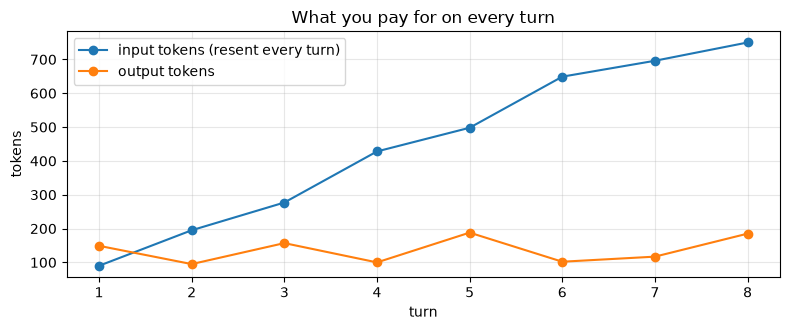

In [20]:
import matplotlib.pyplot as plt

x = range(1, len(turns) + 1)
inputs = [t.usage.prompt_tokens for t in turns]
outputs = [t.usage.completion_tokens for t in turns]

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(x, inputs, marker="o", label="input tokens (resent every turn)")
ax.plot(x, outputs, marker="o", label="output tokens")
ax.set_xlabel("turn"); ax.set_ylabel("tokens")
ax.set_title("What you pay for on every turn")
ax.set_xticks(list(x)); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3b. Check your class's formula

Last week the room derived that the input on turn *k* is `s + (k-1)(u + a) + u`. Test it against your real numbers.

In [21]:
# Estimate the parameters from your own conversation
s = turns[0].usage.prompt_tokens - count("What is a context window?")
u = sum(count(q) for q in questions) // len(questions)
a = sum(t.usage.completion_tokens for t in turns) // len(turns)

print(f"estimated s={s}, u={u}, a={a}")
print()
print(f"{'turn':>5}{'predicted':>12}{'actual':>10}{'error':>9}")
for k in range(1, len(turns) + 1):
    predicted = s + (k - 1) * (u + a) + u
    actual = inputs[k - 1]
    print(f"{k:>5}{predicted:>12,}{actual:>10,}{predicted - actual:>9,}")

estimated s=84, u=8, a=136

 turn   predicted    actual    error
    1          92        90        2
    2         236       195       41
    3         380       277      103
    4         524       428       96
    5         668       498      170
    6         812       649      163
    7         956       696      260
    8       1,100       750      350


The prediction will not be exact — real questions and answers vary in length. What matters is whether the **shape** matches: does the actual line grow the way the formula says it should?

The line grows following the same shape as expected albeit a bit slower.

### 3c. What it would cost at scale

In [22]:
total_in = sum(inputs)
total_out = sum(outputs)
conv_cost = (total_in * IN_RATE + total_out * OUT_RATE) / 1_000_000

print(f"your conversation: {len(turns)} turns, {total_in:,} input + {total_out:,} output tokens")
print(f"cost             : ${conv_cost:.6f}")
print()
for users in (100, 1_000, 10_000):
    print(f"{users:>6,} users, one conversation each per day -> ${conv_cost * users * 30:>10,.2f} / month")

your conversation: 8 turns, 3,583 input + 1,093 output tokens
cost             : $0.002028

   100 users, one conversation each per day -> $      6.08 / month
 1,000 users, one conversation each per day -> $     60.85 / month
10,000 users, one conversation each per day -> $    608.46 / month


### 3d. Truncate the history

The simplest fix: keep only the last few messages. Try it and watch both what you save and what you lose.

In [23]:
def ask_windowed(question, keep=4):
    """Send only the system prompt and the last `keep` messages."""
    history.append({"role": "user", "content": question})
    trimmed = [history[0]] + history[-keep:]
    r = call(trimmed)
    reply = r.choices[0].message.content
    history.append({"role": "assistant", "content": reply})
    print(f"full history would send {sum(count(m['content']) for m in history):>6} tokens")
    print(f"windowed actually sent  {r.usage.prompt_tokens:>6} tokens")
    return reply


print(ask_windowed("What was the first thing I asked you today?"))

full history would send    696 tokens
windowed actually sent     219 tokens
Your first question was: “Summarise everything you have told me.”


**Questions.**

1. How many tokens did the window save?
2. Could it still answer the question about the first thing you asked?
3. So what exactly is the trade-off you just made?

1. 447 tokens.
2. No, it only remembered up to the summarisation question. The rest was cut off from the input and could not be used by the model.
3. There is a trade-off between keeping info in working memory but paying more for keeping that information ready.

This is Lecture 12 in miniature, and the trade-off is not obvious.

---
# Lab 4 — Breaking it on purpose

*Fifteen minutes.*

Everything so far worked. Now make it fail four different ways, and notice that only two of them tell you.

### 4a. Truncation — the silent one

In [24]:
long_q = [{"role": "user", "content": "Explain how hospital triage works in detail."}]

r = call(long_q, max_out=30)

print("content:", repr(r.choices[0].message.content))
print()
print("finish_reason :", r.choices[0].finish_reason)
print("output tokens :", r.usage.completion_tokens)
print()
print("Did an exception get raised?  No.")
print("Is the answer complete?       Look at finish_reason.")

content: ''

finish_reason : length
output tokens : 30

Did an exception get raised?  No.
Is the answer complete?       Look at finish_reason.


### 4b. A broken key

In [25]:
bad = OpenAI(
    api_key="gsk_this_is_not_a_real_key_at_all",
    base_url="https://api.groq.com/openai/v1",
)

try:
    bad.chat.completions.create(
        model=MODEL, messages=[{"role": "user", "content": "hi"}])
except Exception as e:
    print("exception type:", type(e).__name__)
    print("status code   :", getattr(e, "status_code", "n/a"))
    print("message       :", str(e)[:300])

exception type: AuthenticationError
status code   : 401
message       : Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}


### 4c. A model that does not exist

In [26]:
try:
    call([{"role": "user", "content": "hi"}], model="not-a-real-model-9000")
except Exception as e:
    print("exception type:", type(e).__name__)
    print("status code   :", getattr(e, "status_code", "n/a"))
    print("message       :", str(e)[:300])

exception type: NotFoundError
status code   : 404
message       : Error code: 404 - {'error': {'message': 'The model `not-a-real-model-9000` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}


### 4d. The wrapper you keep

Four lines that make the silent failures loud. Use this for the rest of the module.

In [27]:
class BadResponse(Exception):
    pass


def safe_call(messages, **kwargs):
    """A call that refuses to hand you a broken answer."""
    r = call(messages, **kwargs)
    c = r.choices[0]
    if c.finish_reason != "stop":
        raise BadResponse(f"incomplete response: {c.finish_reason}")
    if not (c.message.content or "").strip():
        raise BadResponse("empty response")
    return r


# Works normally...
r = safe_call([{"role": "user", "content": "Say OK."}])
print("ok:", r.choices[0].message.content)

# ...and refuses when the answer is cut off.
try:
    safe_call(long_q, max_out=30)
except BadResponse as e:
    print("caught:", e)

ok: OK.
caught: incomplete response: length


### 4e. Find your actual rate limit

The free tier is limited, but by how much exactly? Do not guess — the provider tells you on **every** response, not just when you break something.

These headers are what next week's retry logic will actually read.

In [32]:
raw = client.chat.completions.with_raw_response.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Say OK."}],
    max_completion_tokens=5,
)

for k in sorted(raw.headers):
    if "ratelimit" in k.lower() or k.lower() == "retry-after":
        print(f"{k:<34}{raw.headers[k]}")

r = raw.parse()   # the ordinary response object, if you still want it
print()
print("content:", r.choices[0].message.content)

x-ratelimit-limit-requests        1000
x-ratelimit-limit-tokens          8000
x-ratelimit-remaining-requests    847
x-ratelimit-remaining-tokens      7921
x-ratelimit-reset-requests        3h40m19.199s
x-ratelimit-reset-tokens          592ms

content: 


**Read those numbers before going on.**

- `x-ratelimit-limit-requests` — how many requests you get per window
- `x-ratelimit-remaining-requests` — how many you have left right now
- `x-ratelimit-limit-tokens` — the same, for tokens
- `x-ratelimit-reset-requests` — how long until it refills

There are **two** limits and you have to stay under both. Which one do you think you are more likely to hit with the short prompts we have been sending?

Sending short prompts means we have a better chance of hitting the remaining requests limit than the remaining tokens limit. However with the reset timer of 38m52.8s in mind we will realistically not be hitting both in this session.

### 4f. Now break it on purpose

A simple loop often will not trigger a 429, because each call takes a second or two of network time — so forty requests can spread across more than a minute and never exceed the limit inside any single window.

To hit it you have to send them **at the same time**. Twenty in flight at once lands them all inside one window.

Set `N` above the limit you just read from the headers.

**Run this cell last.** Afterwards you are throttled for up to a minute, so anything you try straight after will also be refused.

In [33]:
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import time

N = 1600          # set this well above your limit-requests number
WORKERS = 200    # how many are in flight simultaneously

def one(_):
    try:
        call([{"role": "user", "content": "Say OK."}], max_out=5)
        return "ok"
    except Exception as e:
        return f"FAIL {getattr(e, 'status_code', type(e).__name__)}"

start = time.perf_counter()
with ThreadPoolExecutor(max_workers=WORKERS) as pool:
    results = list(pool.map(one, range(N)))
elapsed = time.perf_counter() - start

tally = Counter(results)
print(f"sent {N} requests with {WORKERS} in flight, in {elapsed:.1f}s")
for outcome, n in tally.most_common():
    print(f"  {outcome:<20}{n}")

if any("429" in str(k) for k in tally):
    print("\nYou hit the rate limit. Good - that was the point.")
else:
    print("\nNo 429 yet. Raise N, or raise WORKERS, and run it again.")

sent 1600 requests with 200 in flight, in 34.0s
  FAIL 429            1566
  ok                  34

You hit the rate limit. Good - that was the point.


### 4g. How long until it lets you back in?

Read the headers again, straight after the burst. Compare `remaining-requests` with what you saw in 4e.

In [34]:
try:
    raw = client.chat.completions.with_raw_response.create(
        model=MODEL,
        messages=[{"role": "user", "content": "Say OK."}],
        max_completion_tokens=5,
    )
    headers = raw.headers
    print("Call succeeded - you are back under the limit.")
except Exception as e:
    # A 429 still carries the headers, including retry-after.
    headers = getattr(getattr(e, "response", None), "headers", None) or {}
    print("Still throttled:", getattr(e, "status_code", type(e).__name__))

print()
shown = False
for k in sorted(headers):
    if "ratelimit" in k.lower() or k.lower() == "retry-after":
        print(f"{k:<34}{headers[k]}")
        shown = True
if not shown:
    print("(no rate-limit headers available - wait a minute and run this again)")

Call succeeded - you are back under the limit.

x-ratelimit-limit-requests        1000
x-ratelimit-limit-tokens          8000
x-ratelimit-remaining-requests    813
x-ratelimit-remaining-tokens      7921
x-ratelimit-reset-requests        4h29m16.8s
x-ratelimit-reset-tokens          592ms


If you got a 429 here, look for **retry-after**. That is the provider telling you, in seconds, exactly how long to wait. A program that reads it waits the right amount; a program that guesses waits too long or hammers too soon.

**Questions.**

1. What were your two limits, requests and tokens?
2. How many requests did it take before you were refused?
3. Which of your five failures today raised an exception, and which did not?
4. Sort them into two piles: *my program stopped* and *my program carried on with a bad result*. Which pile is more dangerous?
5. You can see exactly how many requests you have left and exactly when the window resets. Given that, what should a well-written program do instead of just retrying and hoping?

1. 1000 requests and 8000 tokens.
2. It seems I was actually rate-limited because of the 200 workers spamming the endpoint at the same time, as I was rate limited while still having 813 remaining requests.
3. 4b, 4c, 4d, 4f. It should be said however that these exceptions are raised by our own python code and not by the model provider.
4. The program silently carrying on with a bad result is what causes the most problems.
5. A well written program should detect being close to rate limiting and automatically step off the throttle. It will also, if actually being limited, wait for a window reset before trying again. Ideally this is also properly logged. 

Question 5 is next week's lecture in one sentence. Have an answer ready.

---
## Before you leave

- [x] Commit everything: this notebook, your `safe_call` wrapper, your numbers
- [x] Write three sentences at the bottom of this notebook: what surprised you, your Dutch ratio, and what your two rate limits turned out to be
- [x] Run `git ls-files` and confirm `.env` is **not** listed

**Next week:** you found the limit, hit it, and waited. But you also saw that the provider tells you exactly how much room you have left and when it refills — so waiting blindly is not the best you can do. Retries with backoff that read those headers, streaming, running many requests at once, and why a timeout is harder to handle than a clean error.

---

### Your three sentences

> 1. What surprised me was that the models are not deterministic when temperature is set to 0. That's what I had always read about LLMs, and I did not randomness coming from the internal calculations.
>
> 2. My dutch ratio was 1.11x. I had already calculated that in last weeks class as well.
>
> 3. My rate-limits turned out to be 1000 requests and 8000 tokens. It actually took quite some time to reach the request rate limit...